# 미니프로젝트 6: Day 1~6 통합 복습 (Vibe Coding)

#### <목표>
Day1 ~ 6에서 배운 머신러닝 프로세스 전체를 새로운 데이터셋(신용카드 고객 채무불이행)에 자유롭게 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>
- Default of Credit Card Clients (대만 신용카드 고객 채무불이행 데이터)
- 30,000명의 신용카드 고객 정보로 다음 달 채무불이행 여부를 예측

| 변수명 | 설명 |
|:---:|:---|
| LIMIT_BAL | 신용한도 |
| SEX, EDUCATION, MARRIAGE, AGE | 고객 인적사항 |
| PAY_0, PAY_2~PAY_6 | 최근 6개월 월별 연체 상태 (-1: 정상납부, 1 이상: 연체 개월 수) |
| BILL_AMT1~6 | 최근 6개월 청구액 |
| PAY_AMT1~6 | 최근 6개월 납부액 |
| default payment next month | 다음 달 채무불이행 여부 (1: 불이행, 0: 정상) |

#### <실습 태스크>
| 태스크 | 타겟 변수 | 설명 |
|:---:|:---:|:---|
| 분류 | `default payment next month` | 고객 정보로 다음 달 채무불이행 여부 예측 |

1. 각 섹션의 **과제**를 읽고, Day1~6 중 어떤 내용을 적용해야 할지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

- `dataset/day6_miniproject.csv` 파일을 사용하기
- 타겟 변수: `default payment next month` (0: 정상, 1: 채무불이행)

**[과제]** 써니는 신용카드 고객 채무불이행 데이터를 분석하게 되었습니다. 분석에 필요한 라이브러리와 데이터를 불러오는 코드를 AI와 상의해서 작성하세요.

In [1]:
# [Section 0] 분석 준비 — 라이브러리 호출 + 데이터 로드 + 기본 확인

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans, DBSCAN

warnings.filterwarnings("ignore")

# ── 데이터 로드 ──────────────────────────────────────────────────
df = pd.read_csv(os.path.join("dataset", "day6_miniproject.csv"))

# ── 기본 구조 확인 ───────────────────────────────────────────────
print("=== 데이터 크기 ===")
print(f"행: {df.shape[0]:,}  |  열: {df.shape[1]}")

print("\n=== 컬럼 정보 (.info) ===")
df.info()

print("\n=== 기초 통계량 ===")
display(df.describe(include="all").T)

print("\n=== 결측치 현황 ===")
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "명시적 NaN 없음")

# TotalCharges가 object 타입이며 공백 문자열을 결측으로 사용하는 경우가 있음
tc_blank = (df["TotalCharges"].astype(str).str.strip() == "").sum()
print(f"\nTotalCharges 공백 문자열(실질 결측) 수: {tc_blank}건")

print("\n=== 타겟(Churn) 분포 ===")
churn_vc = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True).mul(100).round(1)
display(pd.DataFrame({"count": churn_vc, "pct(%)": churn_pct}))

print("\n=== 상위 5행 ===")
display(df.head())

=== 데이터 크기 ===
행: 7,043  |  열: 21

=== 컬럼 정보 (.info) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== 결측치 현황 ===
명시적 NaN 없음

TotalCharges 공백 문자열(실질 결측) 수: 11건

=== 타겟(Churn) 분포 ===


,count,pct(%)
Churn,,
No,5174,73.5
Yes,1869,26.5



=== 상위 5행 ===


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1) 데이터 탐색 (EDA)

1. Value 기반 탐색 (구조적/통계적)
2. Graph 기반 탐색 (단일 변수/변수 간/여러 변수 간)

**[과제]** 써니는 모델링을 수행하기 전에 필요한 전처리 과정을 파악하기 위해 데이터 탐색(EDA)이 필요하다고 생각했습니다.

AI와 상의하여 데이터의 구조적 정보(변수 타입, 결측치 유무 등)와 통계적 정보(변수별 고유값 개수, 기초통계량 등)를 확인하는 코드를 작성하고, 결과를 분석해 보세요.


**[과제]** 써니는 데이터의 분포에 따라 필요한 전처리와 분석 방법이 달라질 수 있다고 생각했습니다.

AI와 상의하여 범주형 변수와 연속형 변수의 분포를 시각화하고 어떤 전처리와 분석이 필요한지 탐구해 보세요.

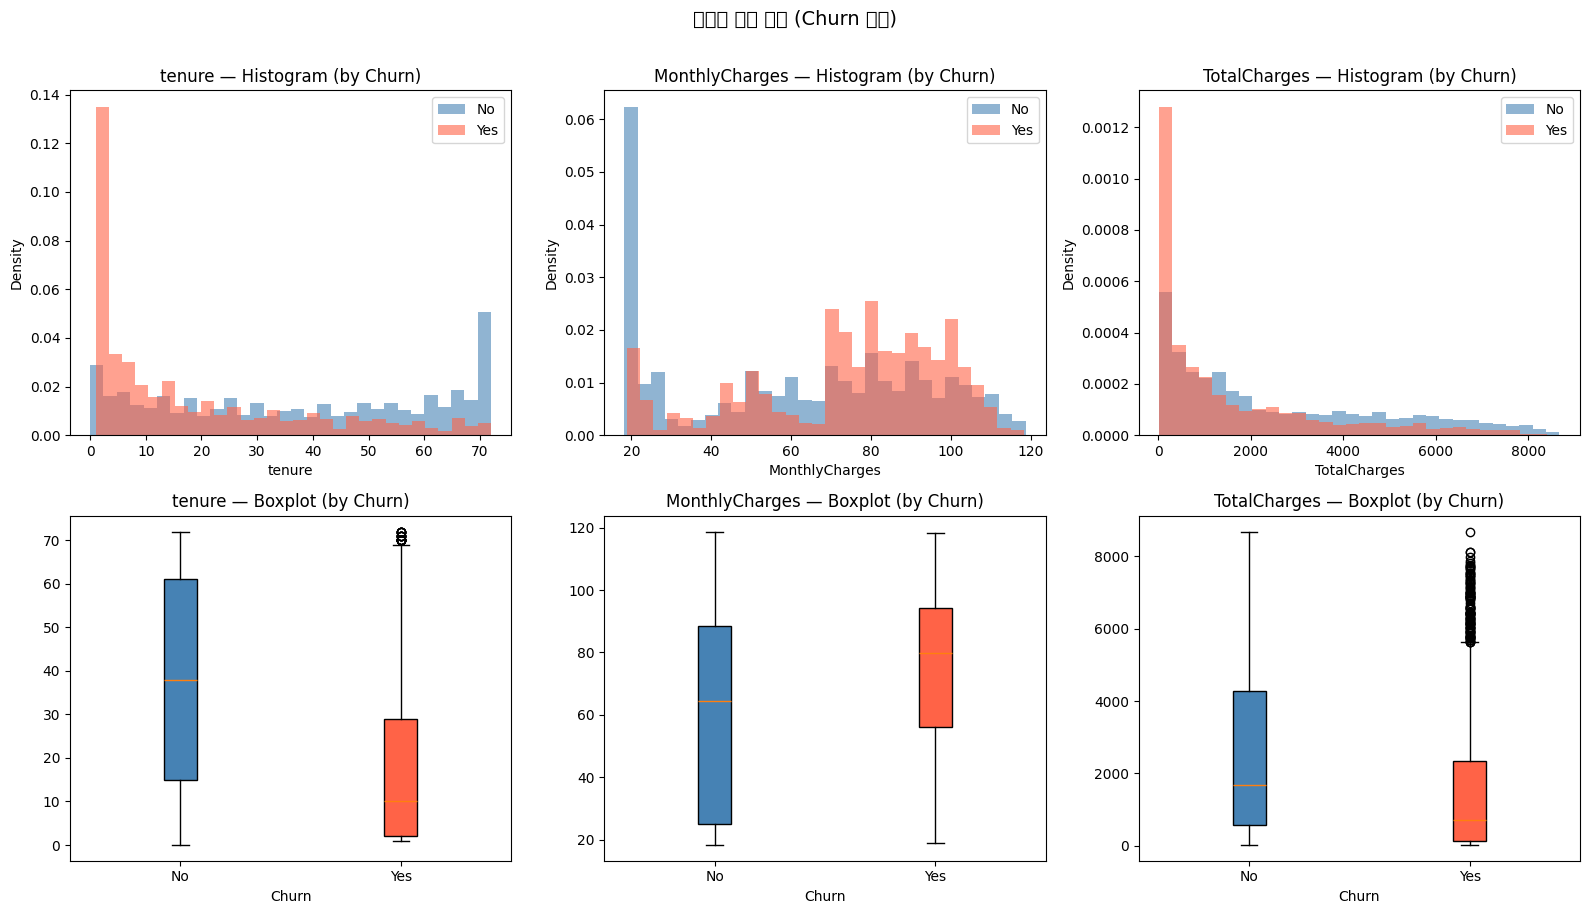

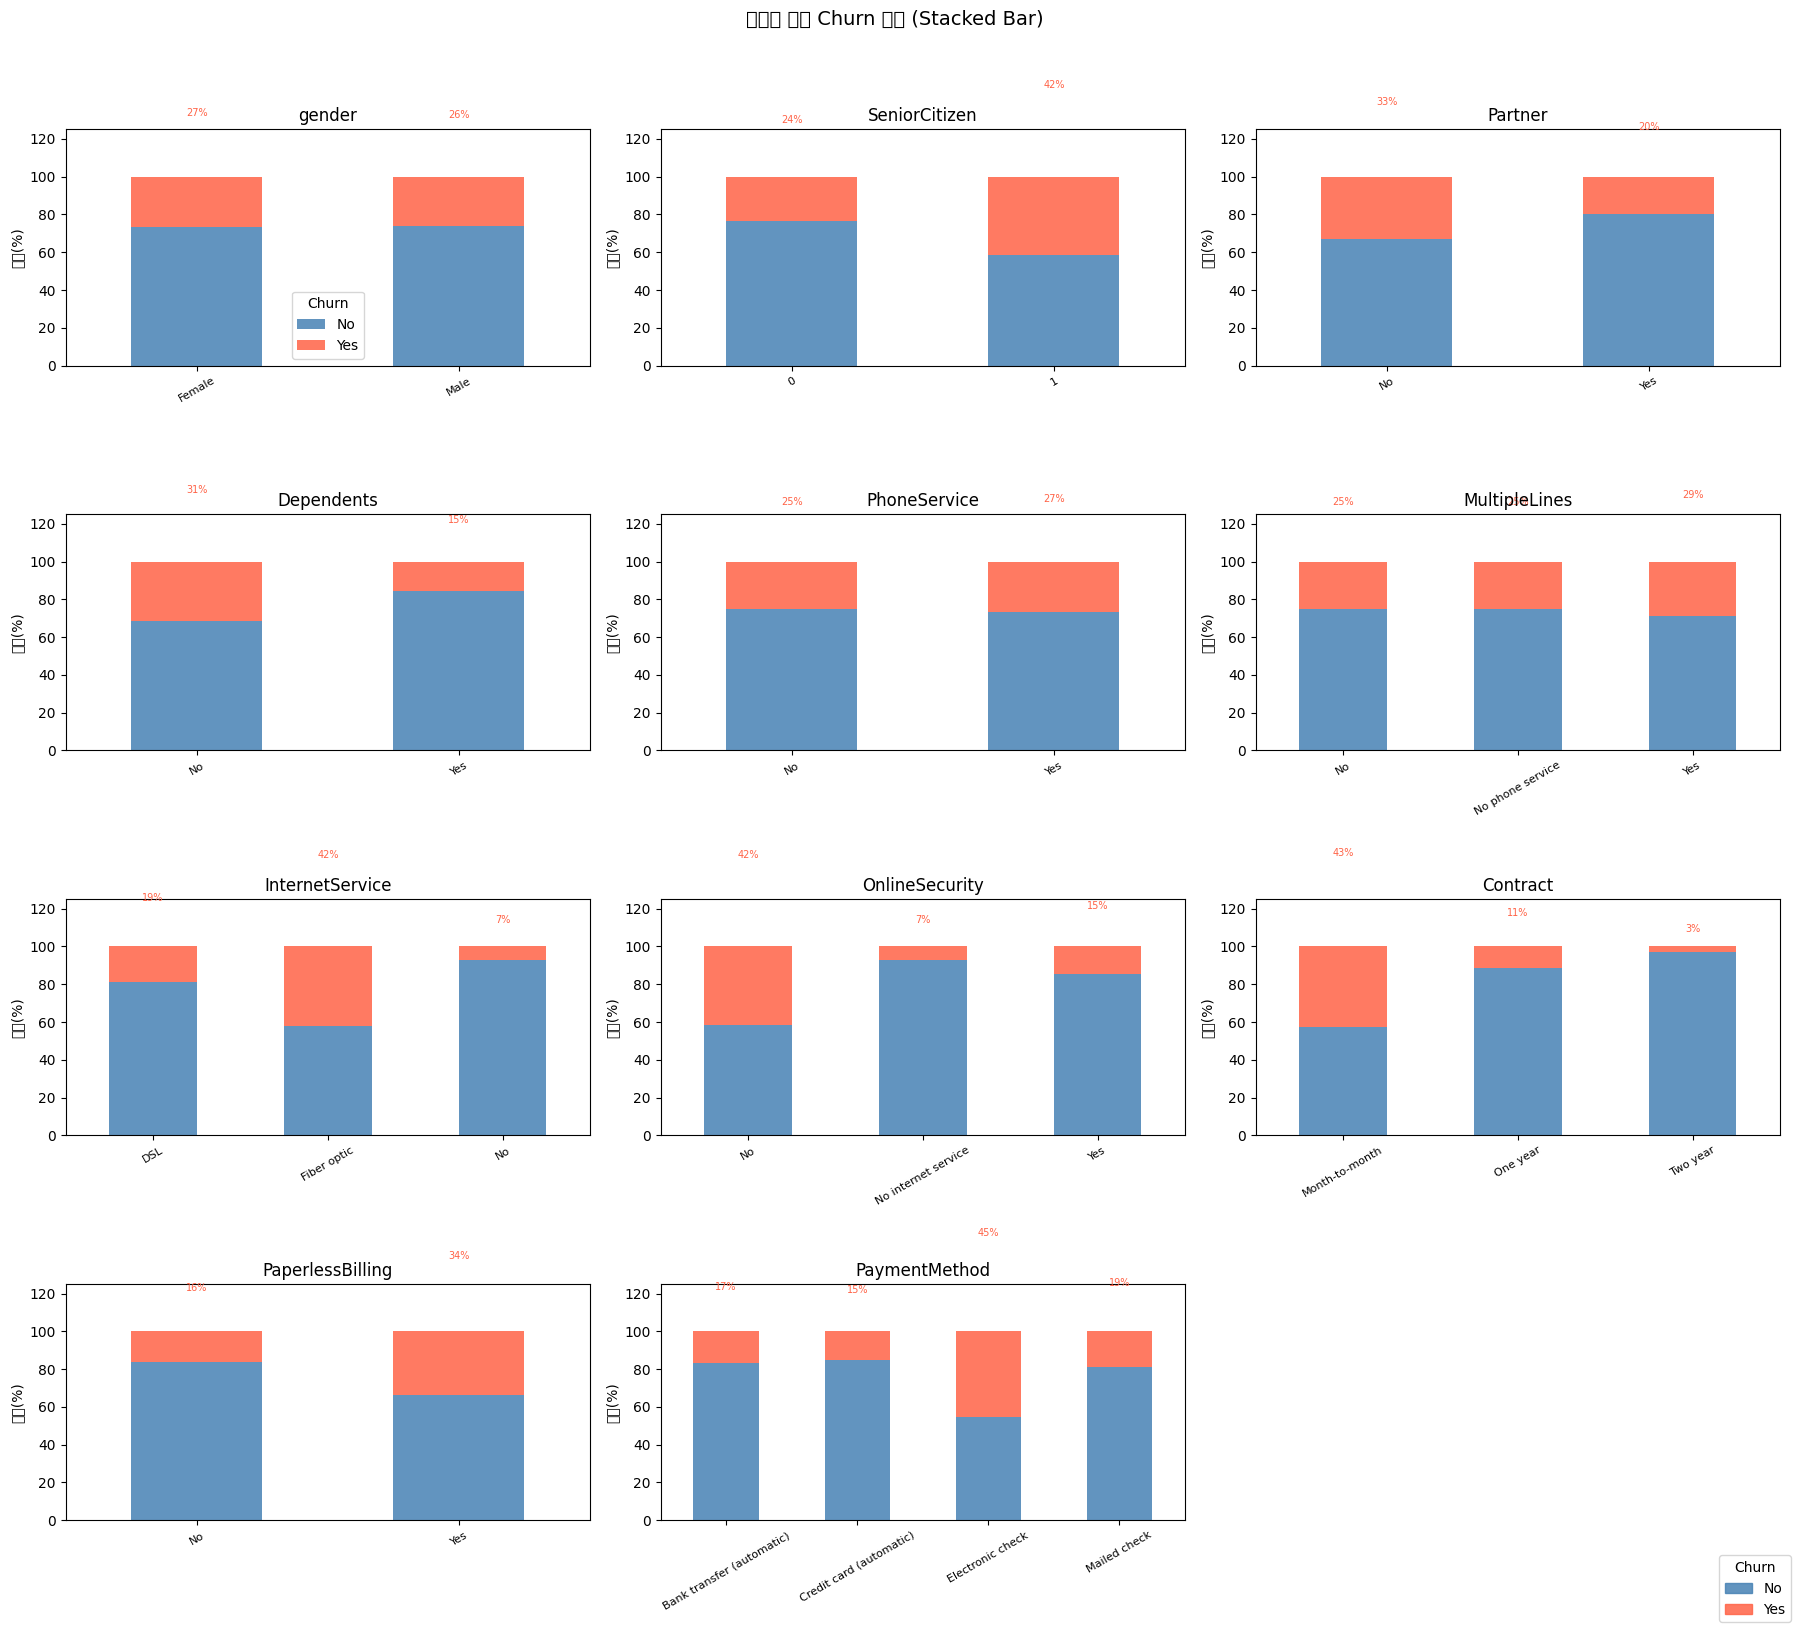

---

## 2) 데이터 전처리

1. 불필요한 변수 제거
2. 다중공선성 해결
3. 결측치 처리
4. 이상치 처리
5. 클래스 불균형 문제 해결
6. 스케일링/인코딩
7. 변수 내 데이터 값을 적절한 값으로 변경 (ex. "Yes" -> 1)

**[과제]** 써니는 EDA 결과를 바탕으로 모델링에 필요한 전처리 과정을 계획하고자 합니다.

AI와 상의하여 필요한 전처리 항목을 나열한 뒤, 학습 데이터와 테스트 데이터 분할 시점을 고려하여 분할 전에 수행해야 하는 전처리와 분할 후에 수행해야 하는 전처리를 구분해 보세요. 

이후 올바른 순서에 따라 전처리를 진행해 보세요.

In [3]:
# [Section 2] 데이터 전처리
# 인코딩 방침:
#   - 이진 범주형(2값): Label Encoding  -> gender, Partner, Dependents, PhoneService, PaperlessBilling
#   - 순서 있는 범주형:  Ordinal(Label) -> Contract (Month-to-month=0, One year=1, Two year=2)
#   - 순서 없는 다중 범주형: One-Hot    -> MultipleLines, InternetService, OnlineSecurity,
#                                          OnlineBackup, DeviceProtection, TechSupport,
#                                          StreamingTV, StreamingMovies, PaymentMethod

df_proc = df.copy()

# 1) 불필요한 변수 제거
df_proc = df_proc.drop(columns=['customerID'])

# 2) TotalCharges: 공백 -> NaN -> float 변환 + 결측 대치
df_proc['TotalCharges'] = pd.to_numeric(df_proc['TotalCharges'], errors='coerce')
tc_median = df_proc['TotalCharges'].median()
blank_n = df_proc['TotalCharges'].isna().sum()
df_proc['TotalCharges'] = df_proc['TotalCharges'].fillna(tc_median)
print(f'TotalCharges 결측 {blank_n}건 -> 중앙값({tc_median:.2f})으로 대치 완료')

# 3) 타겟 인코딩
df_proc['Churn'] = df_proc['Churn'].map({'Yes': 1, 'No': 0})

# 4) 이상치 처리 (IQR 윈저화)
def winsorize_iqr(df_in, cols):
    df_out = df_in.copy()
    for col in cols:
        q1, q3 = df_out[col].quantile(0.25), df_out[col].quantile(0.75)
        iqr = q3 - q1
        df_out[col] = df_out[col].clip(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
    return df_out

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df_proc = winsorize_iqr(df_proc, num_cols)
print('이상치 처리(IQR 윈저화) 완료:', num_cols)

# 5) 학습/테스트 분할 (stratify, 8:2)
X_raw = df_proc.drop(columns=['Churn'])
Y = df_proc['Churn']

X_train_raw, X_test_raw, Y_train, Y_test = train_test_split(
    X_raw, Y, test_size=0.2, random_state=42, stratify=Y
)
print(f'\ntrain: {X_train_raw.shape}, test: {X_test_raw.shape}')
print(f'train Churn 비율: {Y_train.mean():.3f} | test Churn 비율: {Y_test.mean():.3f}')

# 6) 수치형 스케일링 (train fit -> test transform)
scaler = StandardScaler()
X_train_raw = X_train_raw.copy()
X_test_raw  = X_test_raw.copy()
X_train_raw[num_cols] = scaler.fit_transform(X_train_raw[num_cols])
X_test_raw[num_cols]  = scaler.transform(X_test_raw[num_cols])

# 7) 이진 범주형: Label Encoding
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
label_encoders = {}
for col in binary_cols:
    le = LabelEncoder()
    X_train_raw[col] = le.fit_transform(X_train_raw[col].astype(str))
    X_test_raw[col]  = le.transform(X_test_raw[col].astype(str))
    label_encoders[col] = le
print('\n이진 Label Encoding 완료:', binary_cols)

# 8) Contract: Ordinal Encoding (순서 있음)
contract_order = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
X_train_raw['Contract'] = X_train_raw['Contract'].map(contract_order)
X_test_raw['Contract']  = X_test_raw['Contract'].map(contract_order)
print('Contract Ordinal Encoding 완료: Month-to-month=0, One year=1, Two year=2')

# 9) 순서 없는 다중 범주형: One-Hot Encoding
ohe_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaymentMethod'
]
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

ohe.fit(X_train_raw[ohe_cols].astype(str))
ohe_feature_names = ohe.get_feature_names_out(ohe_cols)

train_ohe = pd.DataFrame(
    ohe.transform(X_train_raw[ohe_cols].astype(str)),
    columns=ohe_feature_names, index=X_train_raw.index
)
test_ohe = pd.DataFrame(
    ohe.transform(X_test_raw[ohe_cols].astype(str)),
    columns=ohe_feature_names, index=X_test_raw.index
)

X_train = pd.concat([X_train_raw.drop(columns=ohe_cols), train_ohe], axis=1)
X_test  = pd.concat([X_test_raw.drop(columns=ohe_cols),  test_ohe],  axis=1)
print(f'\nOne-Hot Encoding 완료: {ohe_cols}')

# 최종 확인
print(f'\n=== 전처리 완료 ===')
print(f'X_train shape: {X_train.shape}')
print(f'X_test  shape: {X_test.shape}')
print(f'최종 피처 수: {X_train.shape[1]}')
print('\n피처 목록:')
display(pd.Series(X_train.columns.tolist(), name='feature'))


# ── 10) 다중공선성 확인 및 제거 (|corr| >= 0.7) ───────────────────
# 인코딩 완료 후 X_train 기준으로 상관행렬 계산
corr_matrix = X_train.corr().abs()

# 히트맵 시각화
plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            xticklabels=False, yticklabels=False)
plt.title('Feature Correlation Heatmap (|corr|)')
plt.tight_layout()
plt.show()

# 상삼각 행렬에서 0.7 이상인 쌍 추출 (자기 자신 제외)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'corr'})
    .query('corr >= 0.7')
    .sort_values('corr', ascending=False)
    .reset_index(drop=True)
)
print(f'=== |corr| >= 0.7 쌍: {len(high_corr_pairs)}개 ===')
display(high_corr_pairs)

# 각 쌍에서 두 번째 피처(feature_2)를 제거 대상으로 선정
# → 한 쌍에서 하나만 남기는 표준 방식 (중복 제거 포함)
drop_cols = list(set(high_corr_pairs['feature_2'].tolist()))
X_train = X_train.drop(columns=drop_cols)
X_test  = X_test.drop(columns=drop_cols)

print(f'\n제거된 피처 ({len(drop_cols)}개): {drop_cols}')
print(f'최종 피처 수: {X_train.shape[1]}')

TotalCharges 결측 11건 -> 중앙값(1397.47)으로 대치 완료
이상치 처리(IQR 윈저화) 완료: ['tenure', 'MonthlyCharges', 'TotalCharges']

train: (5634, 19), test: (1409, 19)
train Churn 비율: 0.265 | test Churn 비율: 0.265

이진 Label Encoding 완료: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Contract Ordinal Encoding 완료: Month-to-month=0, One year=1, Two year=2

One-Hot Encoding 완료: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaymentMethod']

=== 전처리 완료 ===
X_train shape: (5634, 38)
X_test  shape: (1409, 38)
최종 피처 수: 38

피처 목록:


0                                      gender
1                               SeniorCitizen
2                                     Partner
3                                  Dependents
4                                      tenure
5                                PhoneService
6                                    Contract
7                            PaperlessBilling
8                              MonthlyCharges
9                                TotalCharges
10                           MultipleLines_No
11             MultipleLines_No phone service
12                          MultipleLines_Yes
13                        InternetService_DSL
14                InternetService_Fiber optic
15                         InternetService_No
16                          OnlineSecurity_No
17         OnlineSecurity_No internet service
18                         OnlineSecurity_Yes
19                            OnlineBackup_No
20           OnlineBackup_No internet service
21                           Onlin

---

## 3) 모델링 및 모델 고도화

1. 단일 모델 (Logistic Regression, Decision Tree)
2. 앙상블 모델 (Random Forest, GBM, XGBoost, LightGBM, CatBoost)

**[과제]** 써니는 본 데이터에 가장 적합한 분류 모델이 무엇인지 알아보고자 합니다.

AI와 상의하여 다양한 분류 모델을 선정하고 학습시키는 코드를 작성한 뒤, Accuracy, Precision, Recall, F1-score, AUC-ROC 등의 분류 평가 지표를 활용하여 모델별 성능을 비교해 보세요.

In [4]:
# [Section 3-1] 단일 모델 + 앙상블 모델 학습 및 성능 비교

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ── 1) 모델 정의 ──────────────────────────────────────────────────
# 단일 모델: Logistic Regression(선형), Decision Tree(비선형 단일 트리)
# 앙상블 모델: RF(배깅), GBM/XGB/LGBM/CatBoost(부스팅 계열)
# class_weight/scale_pos_weight: Churn 불균형(26.5%) 보정
neg_pos_ratio = int((Y_train == 0).sum() / (Y_train == 1).sum())

models = {
    "LogisticRegression" : LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "DecisionTree"       : DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42),
    "RandomForest"       : RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1),
    "GBM"                : GradientBoostingClassifier(n_estimators=200, random_state=42),
    "XGBoost"            : XGBClassifier(n_estimators=200, scale_pos_weight=neg_pos_ratio,
                                         eval_metric="logloss", random_state=42, n_jobs=-1),
    "LightGBM"           : LGBMClassifier(n_estimators=200, class_weight="balanced",
                                          random_state=42, n_jobs=-1, verbose=-1),
    "CatBoost"           : CatBoostClassifier(iterations=200, auto_class_weights="Balanced",
                                              random_seed=42, verbose=0),
}

# ── 2) 학습 및 평가 ───────────────────────────────────────────────
# 평가 지표: Accuracy, Precision, Recall, F1, ROC-AUC
# 불균형 데이터이므로 F1·ROC-AUC 위주로 해석
rows = []
for name, model in models.items():
    model.fit(X_train, Y_train)
    pred  = model.predict(X_test)
    prob  = model.predict_proba(X_test)[:, 1]
    rows.append({
        "Model"    : name,
        "Accuracy" : round(accuracy_score(Y_test, pred), 4),
        "Precision": round(precision_score(Y_test, pred, zero_division=0), 4),
        "Recall"   : round(recall_score(Y_test, pred, zero_division=0), 4),
        "F1"       : round(f1_score(Y_test, pred, zero_division=0), 4),
        "ROC-AUC"  : round(roc_auc_score(Y_test, prob), 4),
    })

# ── 3) 결과 출력 ──────────────────────────────────────────────────
# F1 기준 내림차순 정렬 — Churn 불균형에서 F1이 가장 신뢰성 있는 지표
result_df = pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)
print("=== 모델별 성능 비교 (F1 기준 정렬) ===")
display(result_df)

=== 모델별 성능 비교 (F1 기준 정렬) ===


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,CatBoost,0.7580,0.5310,0.7567,0.6240,0.8404
1,DecisionTree,0.7402,0.5069,0.7888,0.6172,0.8284
2,LightGBM,0.7651,0.5440,0.7112,0.6165,0.8290
3,LogisticRegression,0.7374,0.5034,0.7834,0.6130,0.8415
4,XGBoost,0.7700,0.5619,0.6070,0.5835,0.8158
5,GBM,0.7970,0.6477,0.5160,0.5744,0.8380
6,RandomForest,0.7899,0.6300,0.5053,0.5608,0.8208


**[과제]** 써니는 모델의 성능을 더욱 향상시키고자 합니다.

AI와 상의하여 Grid Search 또는 Random Search를 활용한 하이퍼파라미터 튜닝 코드를 작성하고, 튜닝 전후의 모델 성능을 비교해 보세요.

In [5]:
# [Section 3-2] 하이퍼파라미터 튜닝 (LR/DT: GridSearch, 나머지: RandomSearch)

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint, uniform

# ── 1) 공통 설정 ──────────────────────────────────────────────────
# cv=3: 빠른 탐색을 위해 3-Fold, scoring=F1(불균형 기준)
CV, SCORING, JOBS = 3, "f1", -1

# ── 2) Grid Search: LR, DT (파라미터 공간이 작음) ────────────────
grid_configs = {
    "LogisticRegression": {
        "model": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
        "params": {
            "C": [0.01, 0.1, 1, 10],
            "penalty": ["l1", "l2"],
            "solver": ["liblinear"],
        },
    },
    "DecisionTree": {
        "model": DecisionTreeClassifier(class_weight="balanced", random_state=42),
        "params": {
            "max_depth": [4, 6, 8, 10],
            "min_samples_leaf": [1, 5, 10],
        },
    },
}

grid_results = {}
for name, cfg in grid_configs.items():
    gs = GridSearchCV(cfg["model"], cfg["params"], cv=CV, scoring=SCORING, n_jobs=JOBS)
    gs.fit(X_train, Y_train)
    grid_results[name] = gs.best_estimator_
    print(f"[Grid] {name} best params: {gs.best_params_}")

# ── 3) Random Search: RF, GBM, XGBoost, LightGBM, CatBoost ──────
# n_iter=30: 각 모델당 30회 샘플링 (속도·탐색 균형)
ITER = 30

random_configs = {
    "RandomForest": {
        "model": RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=JOBS),
        "params": {
            "n_estimators": randint(100, 400),
            "max_depth": randint(4, 15),
            "min_samples_leaf": randint(1, 10),
            "max_features": ["sqrt", "log2"],
        },
    },
    "GBM": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "n_estimators": randint(100, 400),
            "learning_rate": uniform(0.01, 0.2),
            "max_depth": randint(3, 8),
            "min_samples_leaf": randint(1, 10),
        },
    },
    "XGBoost": {
        "model": XGBClassifier(scale_pos_weight=neg_pos_ratio, eval_metric="logloss",
                               random_state=42, n_jobs=JOBS),
        "params": {
            "n_estimators": randint(100, 400),
            "learning_rate": uniform(0.01, 0.2),
            "max_depth": randint(3, 8),
            "subsample": uniform(0.6, 0.4),
            "colsample_bytree": uniform(0.6, 0.4),
        },
    },
    "LightGBM": {
        "model": LGBMClassifier(class_weight="balanced", random_state=42, n_jobs=JOBS, verbose=-1),
        "params": {
            "n_estimators": randint(100, 400),
            "learning_rate": uniform(0.01, 0.2),
            "num_leaves": randint(20, 80),
            "min_child_samples": randint(10, 50),
        },
    },
    "CatBoost": {
        "model": CatBoostClassifier(auto_class_weights="Balanced", random_seed=42, verbose=0),
        "params": {
            "iterations": randint(100, 400),
            "learning_rate": uniform(0.01, 0.2),
            "depth": randint(4, 10),
            "l2_leaf_reg": uniform(1, 9),
        },
    },
}

random_results = {}
for name, cfg in random_configs.items():
    rs = RandomizedSearchCV(cfg["model"], cfg["params"], n_iter=ITER,
                            cv=CV, scoring=SCORING, n_jobs=JOBS, random_state=42)
    rs.fit(X_train, Y_train)
    random_results[name] = rs.best_estimator_
    print(f"[Random] {name} best params: {rs.best_params_}")

# ── 4) 튜닝 전/후 성능 비교표 ──────────────────────────────────────
# 튜닝 전 결과(result_df)와 튜닝 후를 나란히 비교
def get_metrics(model, label):
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    return {
        "Model": label,
        "Accuracy" : round(accuracy_score(Y_test, pred), 4),
        "Precision": round(precision_score(Y_test, pred, zero_division=0), 4),
        "Recall"   : round(recall_score(Y_test, pred, zero_division=0), 4),
        "F1"       : round(f1_score(Y_test, pred, zero_division=0), 4),
        "ROC-AUC"  : round(roc_auc_score(Y_test, prob), 4),
    }

tuned_rows = []
for name, model in {**grid_results, **random_results}.items():
    tuned_rows.append(get_metrics(model, name))

tuned_df = pd.DataFrame(tuned_rows).sort_values("F1", ascending=False).reset_index(drop=True)
print("\n=== 튜닝 후 성능 비교 (F1 기준 정렬) ===")
display(tuned_df)

# 최고 F1 모델 저장 (이후 섹션에서 재사용)
best_model_name = tuned_df.iloc[0]["Model"]
best_model = {**grid_results, **random_results}[best_model_name]
print(f"\n최고 성능 모델: {best_model_name}")

[Grid] LogisticRegression best params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
[Grid] DecisionTree best params: {'max_depth': 6, 'min_samples_leaf': 5}
[Random] RandomForest best params: {'max_depth': 7, 'max_features': 'log2', 'min_samples_leaf': 8, 'n_estimators': 314}
[Random] GBM best params: {'learning_rate': np.float64(0.04410482473745831), 'max_depth': 4, 'min_samples_leaf': 4, 'n_estimators': 188}
[Random] XGBoost best params: {'colsample_bytree': np.float64(0.610167650697638), 'learning_rate': np.float64(0.031578285398660894), 'max_depth': 3, 'n_estimators': 151, 'subsample': np.float64(0.8253102287905535)}
[Random] LightGBM best params: {'learning_rate': np.float64(0.021282315805420053), 'min_child_samples': 33, 'n_estimators': 393, 'num_leaves': 21}
[Random] CatBoost best params: {'depth': 4, 'iterations': 152, 'l2_leaf_reg': np.float64(3.078044430599341), 'learning_rate': np.float64(0.05820509320520235)}

=== 튜닝 후 성능 비교 (F1 기준 정렬) ===


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,0.7764,0.5598,0.7380,0.6367,0.8483
1,RandomForest,0.7551,0.5258,0.7914,0.6318,0.8420
2,LightGBM,0.7573,0.5290,0.7807,0.6307,0.8429
3,CatBoost,0.7417,0.5084,0.8048,0.6232,0.8463
4,DecisionTree,0.7410,0.5077,0.7914,0.6186,0.8296
5,LogisticRegression,0.7395,0.5060,0.7834,0.6149,0.8406
6,GBM,0.8034,0.6655,0.5214,0.5847,0.8437



최고 성능 모델: XGBoost


**[과제]** 써니는 변수 선택이 모델 성능 향상에 도움이 되는지 궁금해졌습니다.

AI와 상의하여 본 데이터에 적합한 변수 선택법 (Feature Importance, mRMR, Boruta 등)을 결정하고 관련 코드를 작성해 보세요.

이후 전체 변수를 사용한 경우와 변수 선택법을 적용한 경우의 모델 성능을 비교해 보세요.

[FI] 임계값(gain 하위 25%): 1.32  →  선택 피처: 20개


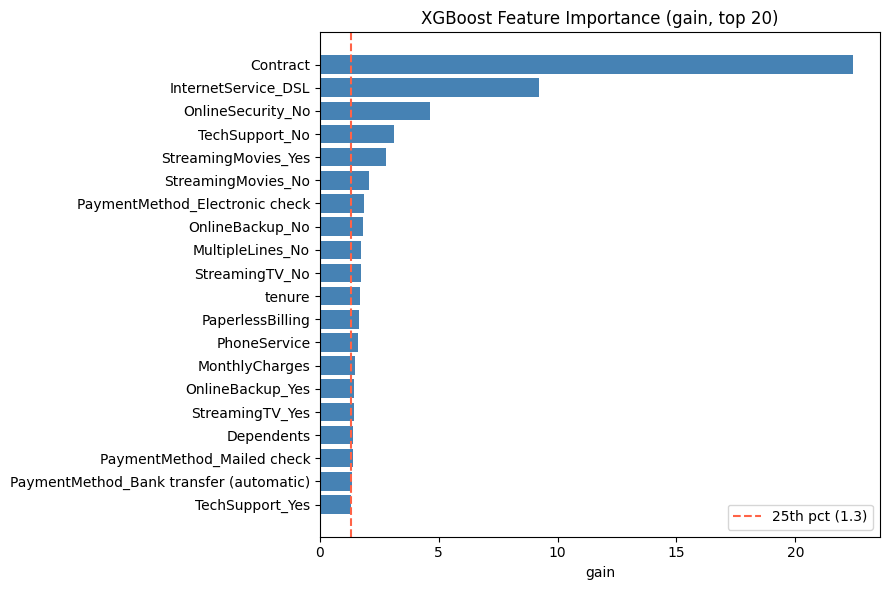

[FI] test F1: 0.5644


100%|██████████| 25/25 [00:03<00:00,  7.43it/s]


[mRMR] K별 CV F1:


,k,CV_F1,CV_std
0,5,0.5861,0.0095
1,10,0.5690,0.0112
2,15,0.5430,0.0185
3,20,0.5426,0.0240
4,25,0.5370,0.0251


[mRMR] best_k=5, test F1: 0.6109
       선택 피처: ['Contract', 'PaymentMethod_Mailed check', 'OnlineSecurity_No', 'InternetService_DSL', 'tenure']
[Boruta] confirmed 피처: 3개  →  ['tenure', 'Contract', 'MonthlyCharges']
[Boruta] test F1: 0.5602
=== 변수 선택 방법별 성능 비교 (F1 기준) ===


,Method,n_features,Accuracy,Precision,Recall,F1,ROC-AUC
0,mRMR (k=5),5,0.7523,0.5239,0.7326,0.6109,0.8108
1,All Features (baseline),27,0.7672,0.5567,0.6043,0.5795,0.8133
2,"FI (gain >= 25th pct, 20개)",20,0.7601,0.5448,0.5856,0.5644,0.8107
3,Boruta (3개),3,0.7459,0.5182,0.6096,0.5602,0.7986


최종 선택: mRMR (k=5)


In [14]:
# [Section 3-3] 변수 선택: Feature Importance / mRMR / Boruta 비교

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from mrmr import mrmr_classif
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

neg_pos_ratio = int((Y_train == 0).sum() / (Y_train == 1).sum())

# ══════════════════════════════════════════════════════════════════
# 방법 1) Feature Importance (XGBoost gain 기준, 하위 25% 제거)
# ══════════════════════════════════════════════════════════════════

# ── 1-1) XGBoost 학습 후 gain importance 추출 ─────────────────────
xgb_base = XGBClassifier(
    n_estimators=200, scale_pos_weight=neg_pos_ratio,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_base.fit(X_train, Y_train)

importance_gain = xgb_base.get_booster().get_score(importance_type='gain')
fi_df = (
    pd.DataFrame({'feature': list(importance_gain.keys()),
                  'gain':    list(importance_gain.values())})
    .sort_values('gain', ascending=False).reset_index(drop=True)
)

# ── 1-2) 하위 25% 임계값 이하 피처 제거 ───────────────────────────
threshold_gain = fi_df['gain'].quantile(0.25)
selected_fi = fi_df.loc[fi_df['gain'] >= threshold_gain, 'feature'].tolist()
print(f"[FI] 임계값(gain 하위 25%): {threshold_gain:.2f}  →  선택 피처: {len(selected_fi)}개")

# ── 1-3) gain bar chart (상위 20개) ──────────────────────────────
top20 = fi_df.head(20)
plt.figure(figsize=(9, 6))
plt.barh(top20['feature'][::-1], top20['gain'][::-1], color='steelblue')
plt.axvline(threshold_gain, color='tomato', linestyle='--', label=f'25th pct ({threshold_gain:.1f})')
plt.title('XGBoost Feature Importance (gain, top 20)')
plt.xlabel('gain')
plt.legend()
plt.tight_layout()
plt.show()

# ── 1-4) FI 선택 변수로 XGBoost 재학습 및 성능 ───────────────────
xgb_fi = XGBClassifier(
    n_estimators=200, scale_pos_weight=neg_pos_ratio,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_fi.fit(X_train[selected_fi], Y_train)
pred_fi = xgb_fi.predict(X_test[selected_fi])
f1_fi = f1_score(Y_test, pred_fi, zero_division=0)
print(f"[FI] test F1: {f1_fi:.4f}")


# ══════════════════════════════════════════════════════════════════
# 방법 2) mRMR (K 후보 5개, Stratified 5-Fold CV + F1 최적화)
# ══════════════════════════════════════════════════════════════════

# ── 2-1) K 후보 및 CV 설정 ────────────────────────────────────────
# 27개 피처에서 고르게 분포하는 5개 후보 선정
k_candidates = [5, 10, 15, 20, 25]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_params = dict(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)

cv_rows = []
for k in k_candidates:
    # mRMR로 k개 피처 선택
    selected_k = mrmr_classif(X=X_train, y=Y_train, K=k)
    fold_f1 = []
    for tr_idx, va_idx in skf.split(X_train, Y_train):
        m = RandomForestClassifier(**rf_params)
        m.fit(X_train.iloc[tr_idx][selected_k], Y_train.iloc[tr_idx])
        p = m.predict(X_train.iloc[va_idx][selected_k])
        fold_f1.append(f1_score(Y_train.iloc[va_idx], p, zero_division=0))
    cv_rows.append({'k': k, 'CV_F1': round(float(np.mean(fold_f1)), 4),
                    'CV_std': round(float(np.std(fold_f1)), 4), 'features': selected_k})

mrmr_cv_df = pd.DataFrame(cv_rows).sort_values('CV_F1', ascending=False).reset_index(drop=True)
print("[mRMR] K별 CV F1:")
display(mrmr_cv_df[['k', 'CV_F1', 'CV_std']])

# ── 2-2) 최적 K로 XGBoost 재학습 ─────────────────────────────────
best_k     = int(mrmr_cv_df.loc[0, 'k'])
selected_mrmr = mrmr_cv_df.loc[0, 'features']
xgb_mrmr = XGBClassifier(
    n_estimators=200, scale_pos_weight=neg_pos_ratio,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_mrmr.fit(X_train[selected_mrmr], Y_train)
pred_mrmr = xgb_mrmr.predict(X_test[selected_mrmr])
f1_mrmr = f1_score(Y_test, pred_mrmr, zero_division=0)
print(f"[mRMR] best_k={best_k}, test F1: {f1_mrmr:.4f}")
print(f"       선택 피처: {selected_mrmr}")


# ══════════════════════════════════════════════════════════════════
# 방법 3) Boruta (perc=95, max_iter=50)
# ══════════════════════════════════════════════════════════════════

# ── 3-1) Boruta 실행 ──────────────────────────────────────────────
rf_boruta = RandomForestClassifier(
    n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1
)
boruta_sel = BorutaPy(
    estimator=rf_boruta, n_estimators='auto',
    max_iter=50, perc=95, random_state=42
)
boruta_sel.fit(X_train.values, Y_train.values)
selected_boruta = X_train.columns[boruta_sel.support_].tolist()

# confirmed가 0이면 weak 포함 상위 10개로 대체
if len(selected_boruta) == 0:
    selected_boruta = X_train.columns[boruta_sel.support_weak_].tolist()[:10]
print(f"[Boruta] confirmed 피처: {len(selected_boruta)}개  →  {selected_boruta}")

# ── 3-2) Boruta 선택 피처로 XGBoost 재학습 ───────────────────────
xgb_boruta = XGBClassifier(
    n_estimators=200, scale_pos_weight=neg_pos_ratio,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_boruta.fit(X_train[selected_boruta], Y_train)
pred_boruta = xgb_boruta.predict(X_test[selected_boruta])
f1_boruta = f1_score(Y_test, pred_boruta, zero_division=0)
print(f"[Boruta] test F1: {f1_boruta:.4f}")


# ══════════════════════════════════════════════════════════════════
# 최종 비교표 → 변수 선택 방법 결정
# ══════════════════════════════════════════════════════════════════
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

def full_metrics(model, feat, label):
    pred = model.predict(X_test[feat])
    prob = model.predict_proba(X_test[feat])[:, 1]
    return {
        'Method':    label,
        'n_features': len(feat),
        'Accuracy':  round(accuracy_score(Y_test, pred), 4),
        'Precision': round(precision_score(Y_test, pred, zero_division=0), 4),
        'Recall':    round(recall_score(Y_test, pred, zero_division=0), 4),
        'F1':        round(f1_score(Y_test, pred, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(Y_test, prob), 4),
    }

# Baseline: 전체 피처 XGBoost
xgb_all = XGBClassifier(
    n_estimators=200, scale_pos_weight=neg_pos_ratio,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_all.fit(X_train, Y_train)

compare_df = pd.DataFrame([
    full_metrics(xgb_all,    X_train.columns.tolist(), 'All Features (baseline)'),
    full_metrics(xgb_fi,     selected_fi,              f'FI (gain >= 25th pct, {len(selected_fi)}개)'),
    full_metrics(xgb_mrmr,   selected_mrmr,            f'mRMR (k={best_k})'),
    full_metrics(xgb_boruta, selected_boruta,           f'Boruta ({len(selected_boruta)}개)'),
]).sort_values('F1', ascending=False).reset_index(drop=True)

print("=== 변수 선택 방법별 성능 비교 (F1 기준) ===")
display(compare_df)

# 최종 선택 모델/피처 저장
best_fs_method = compare_df.iloc[0]['Method']
best_fs_model  = {'All Features (baseline)': (xgb_all,    X_train.columns.tolist()),
                  f'FI (gain >= 25th pct, {len(selected_fi)}개)': (xgb_fi,     selected_fi),
                  f'mRMR (k={best_k})':        (xgb_mrmr,   selected_mrmr),
                  f'Boruta ({len(selected_boruta)}개)': (xgb_boruta, selected_boruta),
                 }.get(best_fs_method, (xgb_all, X_train.columns.tolist()))
best_model_final, best_features_final = best_fs_model
print(f"최종 선택: {best_fs_method}")

**[과제]** 써니는 클래스 불균형을 완화하면 모델 성능이 향상될 것이라고 생각했습니다.

AI와 상의하여 Resampling (TomekLinks, SMOTE, TomekLinks+SMOTE, ADASYN 등) 또는 One-Class Learning (SVDD 등) 중 본 데이터에 적합한 방법을 선택하고 적용해 보세요.

이후 적용 전후의 모델 성능을 비교해 보세요.

## 6) 모델 해석

1. SHAP Value
2. Clustering 기반 RCA
3. STUCCO 기반 RCA

**[과제]** 써니는 최종 모델의 예측 결과를 해석하고자 합니다.

가장 예측력이 좋았던 전처리 방법, 모델, 모델 고도화 방법의 조합을 선택한 뒤, AI와 상의하여 적절한 모델 해석 기법을 적용해 보세요.

이를 바탕으로 "어떤 고객이 채무불이행 위험이 높은지"를 한 문단으로 정리해 보세요.